n:       [3, 10, 100, 300]
Gauss:   [3.1e-6, 2.6e-6, 0.0002932, 0.0075033]
Cholesky:[8.2e-6, 1.8e-6, 0.0002227, 0.0119722]


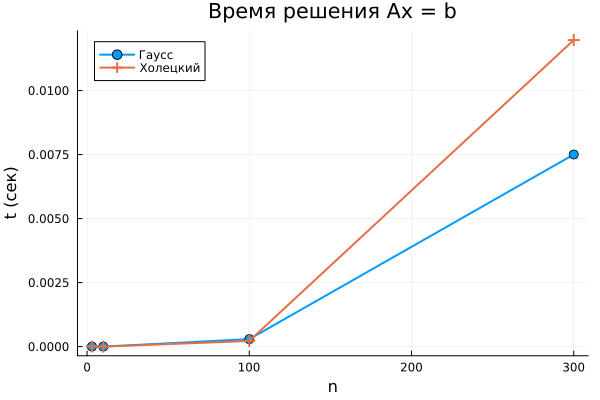

In [1]:
# 20:10 - 5 баллов
using LinearAlgebra
using Random
using Plots

function FORTRAN_CHOLESKY(A, N)
    for I in 1:N
        S = A[I,I]

        for IP in 1:I-1
            S -= A[I,IP] * A[I,IP]
        end
        A[I,I] = sqrt(S)

        for J in I+1:N
            S = A[J,I]

            for IP in 1:I-1
                S -= A[I,IP] * A[J,IP]
            end

            A[J,I] = S / A[I,I]
        end
    end
    return A
end


function cholesky_solve(A, b)
    n = size(A, 1)
    L = copy(A)
    FORTRAN_CHOLESKY(L, n)

    L1 = reverse(reverse(L, dims=1), dims=2)
    b1 = reverse(b)

    z  = back_substitution(L1, b1)
    y  = reverse(z)

    # Lᵀ x = y
    x = back_substitution(L', y)

    return x
end

function back_substitution(U, y)
    n = size(U,1)
    x = zeros(Float64, n)
    for i in n:-1:1
        s = 0.0
        for j in i+1:n
            s += U[i,j]*x[j]
        end
        x[i] = (y[i] - s) / U[i,i]
    end
    return x
end

function gauss_no_pivot(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    for k in 1:n-1
        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end
    return back_substitution(A, b)
end


function make_SPD_matrix(n)
    M = randn(n, n)
    A = M' * M
    A += n * I
    return A
end

ns = [3, 10, 100, 300]
t_gauss = Float64[]
t_chol  = Float64[]

# Прогрев (чтобы скомпилировалось)
A_test = make_SPD_matrix(5)
b_test = randn(5)
gauss_no_pivot(A_test, b_test)
cholesky_solve(A_test, b_test)

for n in ns
    A = make_SPD_matrix(n)
    b = randn(n)

    push!(t_gauss, @elapsed gauss_no_pivot(A, b))
    push!(t_chol,  @elapsed cholesky_solve(A, b))
end

println("n:       ", ns)
println("Gauss:   ", t_gauss)
println("Cholesky:", t_chol)

plot(
    ns, t_gauss;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    linewidth = 2,
    label = "Гаусс",
    xlabel = "n",
    ylabel = "t (сек)",
    title = "Время решения Ax = b"
)

plot!(
    ns, t_chol;
    seriestype = :path,
    marker = :+,
    markersize = 6,
    linewidth = 2,
    label = "Холецкий"
)

In [2]:
using LinearAlgebra
using Random
using Plots

A_fixed = [
    4.0 1.0 1.0
    1.0 3.0 0.0
    1.0 0.0 2.0
]
b_fixed = [1.0, 2.0, 3.0]

println("=== SOLUTIONS ===")

println("Gauss no pivot:")
println(gauss_no_pivot(A_fixed, b_fixed))

println("Cholesky:")
println(cholesky_solve(A_fixed, b_fixed))


=== SOLUTIONS ===
Gauss no pivot:
[-0.368421052631579, 0.7894736842105263, 1.6842105263157896]
Cholesky:
[-0.36842105263157887, 0.7894736842105262, 1.6842105263157894]
